## Build dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_selection import chi2, SelectKBest, SelectPercentile
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
n = 1000

df = pd.DataFrame({
    # Strongly related to result
    'has_internet'     : np.random.choice([0, 1], n,
                          p=[0.3, 0.7]),
    # ↑ 70% have internet
    #   internet → more resources → likely to pass

    'attends_tutoring' : np.random.choice([0, 1], n,
                          p=[0.5, 0.5]),
    # ↑ 50% attend tutoring sessions

    'has_textbooks'    : np.random.choice([0, 1], n,
                          p=[0.2, 0.8]),
    # ↑ 80% have required textbooks

    # Weakly related
    'exercises'        : np.random.choice([0, 1], n,
                          p=[0.4, 0.6]),
    # ↑ physical exercise has slight effect

    'has_study_group'  : np.random.choice([0, 1], n,
                          p=[0.5, 0.5]),
    # ↑ study groups have small effect

    # Completely unrelated (noise)
    'is_lefthanded'    : np.random.choice([0, 1], n,
                          p=[0.1, 0.9]),
    # ↑ being left handed has nothing to do with results

    'lucky_number_odd' : np.random.choice([0, 1], n,
                          p=[0.5, 0.5]),
    # ↑ pure noise

    'born_in_summer'   : np.random.choice([0, 1], n,
                          p=[0.25, 0.75]),
    # ↑ birth season has nothing to do with results
})

# Create target — strongly influenced by key features
score = (
    df['has_internet']     * 15 +
    df['attends_tutoring'] * 12 +
    df['has_textbooks']    * 10 +
    df['exercises']        *  5 +
    df['has_study_group']  *  3 +
    np.random.normal(0, 8, n)   # noise
)
df['result'] = (score > score.median()).astype(int)

X = df.drop('result', axis=1)
y = df['result']
feature_names = X.columns.tolist()

print("Dataset created:")
print(f"  Features : {feature_names}")
print(f"  Samples  : {n}")
print(f"\nClass distribution:")
print(f"  Pass: {y.sum()}  Fail: {(y==0).sum()}")

Dataset created:
  Features : ['has_internet', 'attends_tutoring', 'has_textbooks', 'exercises', 'has_study_group', 'is_lefthanded', 'lucky_number_odd', 'born_in_summer']
  Samples  : 1000

Class distribution:
  Pass: 500  Fail: 500


# Step 1 — Manual Chi-Square Calculation

In [2]:
# Calculate chi-square manually for each feature
# to understand what sklearn does internally

print("\nManual Chi-Square Calculation:")
print(f"\n{'Feature':<20} {'χ² Score':>10} {'P-Value':>12} "
      f"{'Relationship':>15}")
print("─" * 62)

manual_results = {}

for feature in feature_names:
    # Build contingency table
    contingency = pd.crosstab(X[feature], y)
    # ↑ rows = feature values (0 or 1)
    #   columns = class labels (0=Fail, 1=Pass)
    #   cells = counts

    # scipy calculates chi-square from contingency table
    chi2_stat, p_val, dof, expected = chi2_contingency(contingency)
    # chi2_stat = chi-square statistic
    # p_val     = probability of this result by chance
    # dof       = degrees of freedom
    # expected  = expected counts if independent

    relationship = "✅ Strong" if p_val < 0.01  else \
                   "⚠️  Weak"   if p_val < 0.05  else \
                   "❌ None"

    manual_results[feature] = {
        'Chi2'    : chi2_stat,
        'P_Value' : p_val,
        'DOF'     : dof,
        'Expected': expected
    }

    print(f"{feature:<20} {chi2_stat:>10.4f} {p_val:>12.6f} "
          f"{relationship:>15}")


Manual Chi-Square Calculation:

Feature                χ² Score      P-Value    Relationship
──────────────────────────────────────────────────────────────
has_internet           176.8375     0.000000        ✅ Strong
attends_tutoring       168.2723     0.000000        ✅ Strong
has_textbooks           52.0061     0.000000        ✅ Strong
exercises               19.5971     0.000010        ✅ Strong
has_study_group         13.4565     0.000244        ✅ Strong
is_lefthanded            2.1586     0.141773          ❌ None
lucky_number_odd         0.1962     0.657805          ❌ None
born_in_summer           1.3143     0.251611          ❌ None


# Step 2 — Show Contingency Tables

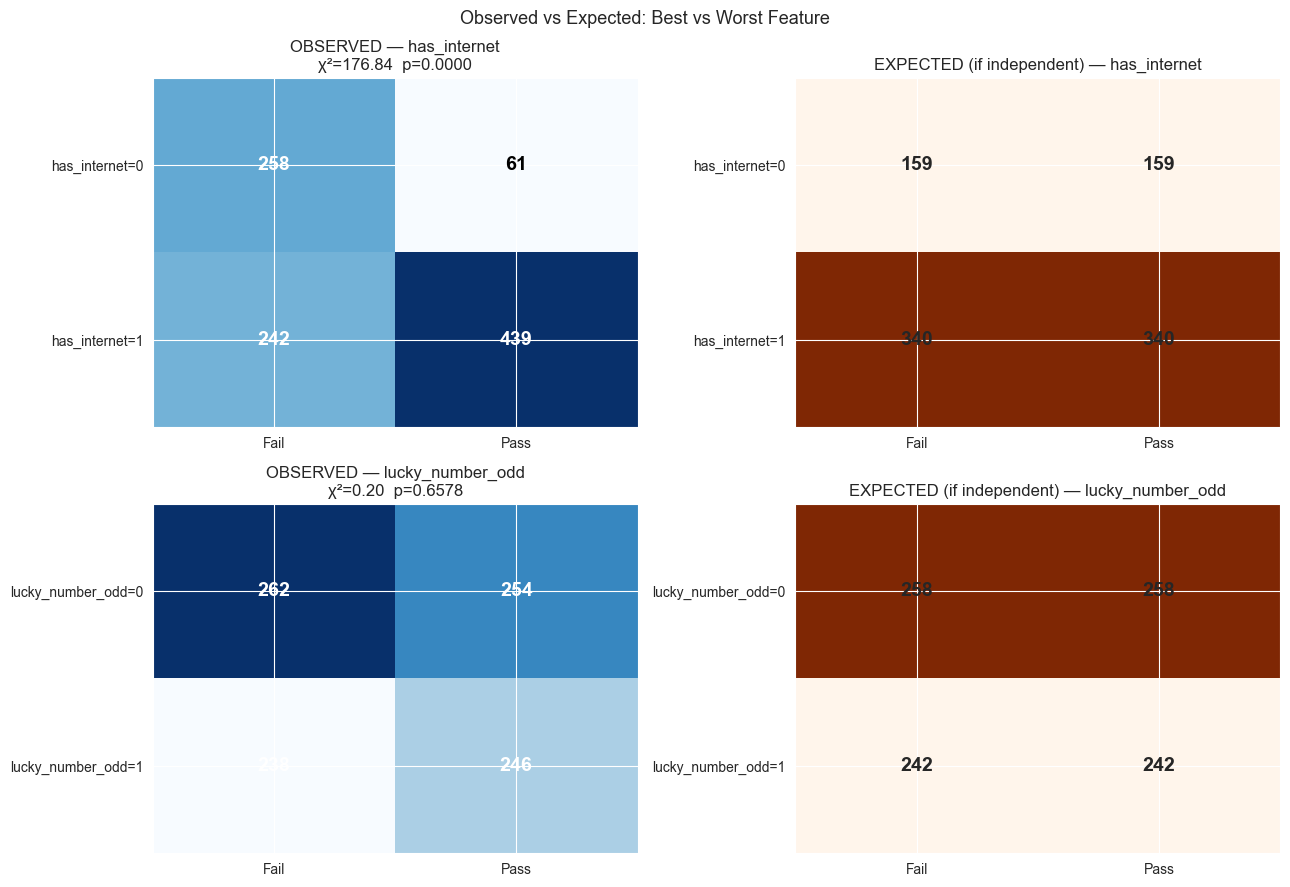

In [3]:
# Visualize observed vs expected for top and bottom features
best_feature  = max(manual_results,
                    key=lambda x: manual_results[x]['Chi2'])
worst_feature = min(manual_results,
                    key=lambda x: manual_results[x]['Chi2'])

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for row, feature in enumerate([best_feature, worst_feature]):
    contingency = pd.crosstab(X[feature], y,
                               rownames=[feature],
                               colnames=['Result'])
    expected_arr = manual_results[feature]['Expected']
    chi2_val     = manual_results[feature]['Chi2']
    p_val        = manual_results[feature]['P_Value']

    # Observed
    obs_data = contingency.values
    im1 = axes[row, 0].imshow(obs_data, cmap='Blues', aspect='auto')
    axes[row, 0].set_xticks([0, 1])
    axes[row, 0].set_yticks([0, 1])
    axes[row, 0].set_xticklabels(['Fail', 'Pass'])
    axes[row, 0].set_yticklabels([f'{feature}=0', f'{feature}=1'])
    axes[row, 0].set_title(f"OBSERVED — {feature}\n"
                            f"χ²={chi2_val:.2f}  p={p_val:.4f}")
    for i in range(2):
        for j in range(2):
            axes[row, 0].text(j, i, f'{obs_data[i,j]}',
                               ha='center', va='center',
                               fontsize=14, fontweight='bold',
                               color='white' if obs_data[i,j] > obs_data.max()/2
                               else 'black')

    # Expected
    exp_data = expected_arr.astype(int)
    axes[row, 1].imshow(exp_data, cmap='Oranges', aspect='auto')
    axes[row, 1].set_xticks([0, 1])
    axes[row, 1].set_yticks([0, 1])
    axes[row, 1].set_xticklabels(['Fail', 'Pass'])
    axes[row, 1].set_yticklabels([f'{feature}=0', f'{feature}=1'])
    axes[row, 1].set_title(f"EXPECTED (if independent) — {feature}")
    for i in range(2):
        for j in range(2):
            axes[row, 1].text(j, i, f'{exp_data[i,j]}',
                               ha='center', va='center',
                               fontsize=14, fontweight='bold')

plt.suptitle("Observed vs Expected: Best vs Worst Feature",
             fontsize=13)
plt.tight_layout()
plt.show()

# Step 3 — sklearn's chi2 Function

In [4]:
# chi2 in sklearn works the same as chi2_contingency
# but processes ALL features at once

# IMPORTANT: chi2 requires non-negative values
# Our binary features are already 0/1 so no scaling needed
# For continuous features you would do:
#   X_scaled = MinMaxScaler().fit_transform(X_continuous)
#   then apply chi2

chi2_scores, p_values = chi2(X, y)
# Returns:
#   chi2_scores = array of chi-square stats per feature
#   p_values    = array of p-values per feature

results_df = pd.DataFrame({
    'Feature'  : feature_names,
    'Chi2'     : chi2_scores,
    'P_Value'  : p_values,
}).sort_values('Chi2', ascending=False)

print("\nSklearn chi2 Results:")
print(results_df.round(4).to_string(index=False))


Sklearn chi2 Results:
         Feature    Chi2  P_Value
attends_tutoring 82.2403   0.0000
    has_internet 56.9883   0.0000
   has_textbooks 10.2615   0.0014
       exercises  8.3904   0.0038
 has_study_group  7.0040   0.0081
  born_in_summer  0.3932   0.5306
   is_lefthanded  0.2503   0.6169
lucky_number_odd  0.1322   0.7161


# Step 4 — Visualize Chi-Square Scores

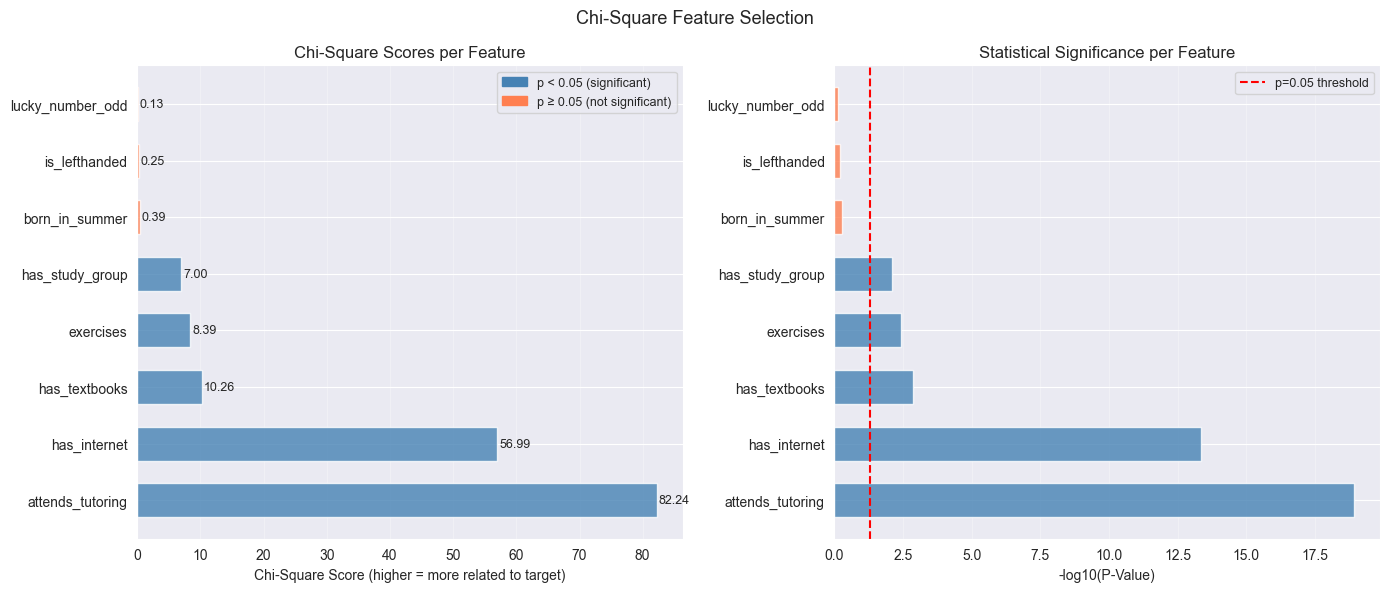

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Color based on significance
colors = ['steelblue' if p < 0.05 else 'coral'
          for p in results_df['P_Value']]

# Plot 1 — Chi-Square scores
bars = axes[0].barh(
    results_df['Feature'],
    results_df['Chi2'],
    color  = colors,
    alpha  = 0.8,
    height = 0.6
)
for bar, val in zip(bars, results_df['Chi2']):
    axes[0].text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height()/2,
        f'{val:.2f}',
        va='center', fontsize=9
    )
axes[0].set_xlabel("Chi-Square Score (higher = more related to target)")
axes[0].set_title("Chi-Square Scores per Feature")
axes[0].grid(True, alpha=0.3, axis='x')

from matplotlib.patches import Patch
legend = [Patch(color='steelblue', label='p < 0.05 (significant)'),
          Patch(color='coral',     label='p ≥ 0.05 (not significant)')]
axes[0].legend(handles=legend, fontsize=9)

# Plot 2 — P-values transformed
p_log = -np.log10(results_df['P_Value'] + 1e-300)
p_colors = ['steelblue' if p < 0.05 else 'coral'
            for p in results_df['P_Value']]

axes[1].barh(results_df['Feature'], p_log,
             color=p_colors, alpha=0.8, height=0.6)
threshold = -np.log10(0.05)
axes[1].axvline(x=threshold, color='red',
                linestyle='--', linewidth=1.5,
                label='p=0.05 threshold')
axes[1].set_xlabel("-log10(P-Value)")
axes[1].set_title("Statistical Significance per Feature")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3, axis='x')

plt.suptitle("Chi-Square Feature Selection", fontsize=13)
plt.tight_layout()
plt.show()

# Step 5 — SelectKBest with Chi-Square

In [6]:
# Select top K features automatically

for k in [3, 5, 6]:
    selector = SelectKBest(
        score_func = chi2,
        # ↑ use chi-square as scoring function
        k          = k
    )
    selector.fit(X, y)

    selected = [f for f, s in zip(feature_names,
                                   selector.get_support()) if s]
    removed  = [f for f, s in zip(feature_names,
                                   selector.get_support()) if not s]

    print(f"SelectKBest (K={k}):")
    print(f"  Selected : {selected}")
    print(f"  Removed  : {removed}\n")

SelectKBest (K=3):
  Selected : ['has_internet', 'attends_tutoring', 'has_textbooks']
  Removed  : ['exercises', 'has_study_group', 'is_lefthanded', 'lucky_number_odd', 'born_in_summer']

SelectKBest (K=5):
  Selected : ['has_internet', 'attends_tutoring', 'has_textbooks', 'exercises', 'has_study_group']
  Removed  : ['is_lefthanded', 'lucky_number_odd', 'born_in_summer']

SelectKBest (K=6):
  Selected : ['has_internet', 'attends_tutoring', 'has_textbooks', 'exercises', 'has_study_group', 'born_in_summer']
  Removed  : ['is_lefthanded', 'lucky_number_odd']



# Step 6 — Chi-Square with Continuous Features (Binning)

In [7]:
# For continuous features we must bin them first
# before applying chi-square

np.random.seed(42)
n = 1000
df_cont = pd.DataFrame({
    'study_hours'   : np.random.normal(6, 2, n).clip(0, 12),
    'sleep_hours'   : np.random.normal(7, 1.5, n).clip(3, 10),
    'attendance_pct': np.random.normal(75, 15, n).clip(0, 100),
    'lucky_number'  : np.random.uniform(0, 100, n),
})

score_c = (
    df_cont['study_hours']    * 4.0 +
    df_cont['attendance_pct'] * 0.3 +
    np.random.normal(0, 5, n)
)
y_cont = (score_c > score_c.median()).astype(int)

# Method 1: Bin into categories then apply chi2
df_binned = pd.DataFrame()
n_bins    = 5

for col in df_cont.columns:
    df_binned[col] = pd.cut(
        df_cont[col],
        bins   = n_bins,
        labels = False
    ).astype(float)
    # ↑ divides continuous range into 5 equal bins
    #   labels=False → bin numbers (0,1,2,3,4)

print("Binned continuous features:")
print(df_binned.head())

chi2_scores_c, p_values_c = chi2(df_binned, y_cont)
print("\nChi-Square on binned continuous features:")
for feat, score, pval in zip(df_cont.columns,
                              chi2_scores_c, p_values_c):
    flag = "✅" if pval < 0.05 else "❌"
    print(f"  {feat:<20} χ²={score:>8.3f}  p={pval:.4f}  {flag}")

# Method 2: MinMaxScaler then apply chi2
# (works but binning is more interpretable)
scaler    = MinMaxScaler()
X_scaled  = scaler.fit_transform(df_cont)
# ↑ scales all values to [0, 1] range
#   non-negative → valid for chi2
#   but chi2 on continuous values is less meaningful
#   than chi2 on categorical/binned values

chi2_scores_s, p_values_s = chi2(X_scaled, y_cont)
print("\nChi-Square on MinMaxScaled continuous features:")
for feat, score, pval in zip(df_cont.columns,
                              chi2_scores_s, p_values_s):
    flag = "✅" if pval < 0.05 else "❌"
    print(f"  {feat:<20} χ²={score:>8.3f}  p={pval:.4f}  {flag}")

Binned continuous features:
   study_hours  sleep_hours  attendance_pct  lucky_number
0          2.0          4.0             2.0           4.0
1          2.0          3.0             3.0           4.0
2          3.0          2.0             2.0           1.0
3          3.0          2.0             2.0           4.0
4          2.0          3.0             1.0           2.0

Chi-Square on binned continuous features:
  study_hours          χ²= 125.066  p=0.0000  ✅
  sleep_hours          χ²=   0.060  p=0.8070  ❌
  attendance_pct       χ²=  39.863  p=0.0000  ✅
  lucky_number         χ²=   0.086  p=0.7693  ❌

Chi-Square on MinMaxScaled continuous features:
  study_hours          χ²=  20.721  p=0.0000  ✅
  sleep_hours          χ²=   0.023  p=0.8793  ❌
  attendance_pct       χ²=   7.670  p=0.0056  ✅
  lucky_number         χ²=   0.041  p=0.8403  ❌


# Step 7 — Pipeline with Chi-Square

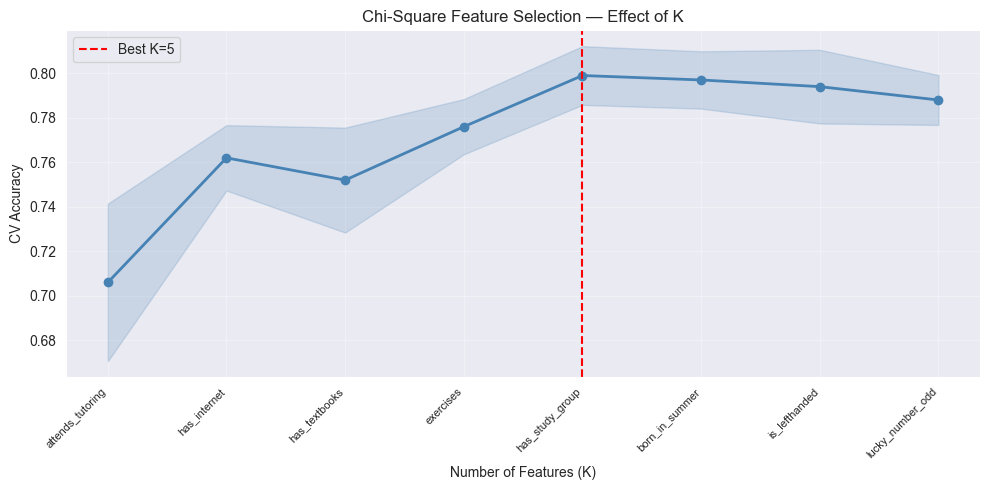

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

k_values = range(1, len(feature_names)+1)
cv_means = []
cv_stds  = []

for k in k_values:
    pipe = Pipeline([
        ('selector', SelectKBest(chi2, k=k)),
        # ↑ chi-square selection inside pipeline
        #   prevents leakage: selection fitted on
        #   train fold only within each CV fold
        ('model',    RandomForestClassifier(
                         n_estimators=100,
                         random_state=42))
    ])
    scores = cross_val_score(pipe, X, y, cv=5,
                              scoring='accuracy')
    cv_means.append(scores.mean())
    cv_stds.append(scores.std())

plt.figure(figsize=(10, 5))
plt.plot(k_values, cv_means, marker='o',
         color='steelblue', linewidth=2)
plt.fill_between(k_values,
                 np.array(cv_means) - np.array(cv_stds),
                 np.array(cv_means) + np.array(cv_stds),
                 alpha=0.2, color='steelblue')

best_k = k_values[np.argmax(cv_means)]
plt.axvline(x=best_k, color='red', linestyle='--',
            label=f'Best K={best_k}')

plt.xlabel("Number of Features (K)")
plt.ylabel("CV Accuracy")
plt.title("Chi-Square Feature Selection — Effect of K")
plt.xticks(k_values,
           [results_df['Feature'].iloc[i-1] for i in k_values],
           rotation=45, ha='right', fontsize=8)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()